In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import pandas as pd
import numpy as np
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "utils"))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "prompt"))
import env_loader
env_loader.load_env()
from utils import generate_mixed_violin_plot, generate_multi_delta_violin_plot

In [3]:
WORK_DIR = os.environ.get("WORK_DIR_HOME", "")
results_dir_parent = os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage1')
agg_df_train = pd.read_csv(f"{results_dir_parent}/aggregate_statistics_stage1.csv", header=0)
agg_df_train

,Target,AUC,n_samples,mean_proba,CI,LLM_name,prompt_num,tabular,n_few_shot,target_type,task_phrase,cot,persona
0,target-hemoglobin-grade2plus,0.588006,597,0.543467,"[0.550, 0.631]",Llama3.1-8B-Q6-K,9,note-tabular,8,lab,non-simplified,cot,med-onc
1,target-hemoglobin-grade2plus,0.582508,597,0.662797,"[0.537, 0.626]",Llama3.1-8B-Q6-K,40,note,0,lab,simplified,no cot,ai-model
2,target-hemoglobin-grade2plus,0.617469,597,0.604439,"[0.572, 0.660]",Llama3.1-8B-Q6-K,8,note,8,lab,non-simplified,no cot,med-onc
3,target-hemoglobin-grade2plus,0.612586,596,0.617785,"[0.569, 0.659]",Llama3.1-8B-Q6-K,17,note,4,lab,non-simplified,cot,ai-model
4,target-hemoglobin-grade2plus,0.605429,593,0.645868,"[0.560, 0.650]",Llama3.1-8B-Q6-K,16,note-tabular,16,lab,non-simplified,no cot,ai-model
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3643,target-ED-visit,0.645461,600,0.523167,"[0.605, 0.690]",Mistral-Nemo-2407-IQ4-XS,40,note-tabular,8,clinic,simplified,no cot,ai-model
3644,target-ED-visit,0.679528,600,0.390250,"[0.641, 0.717]",Qwen2.5-14B-IQ4-XS,8,note-tabular,4,clinic,non-simplified,no cot,med-onc
3645,target-ED-visit,0.644844,599,0.561770,"[0.602, 0.690]",Llama3.1-8B-Q6-K,33,note-tabular,4,clinic,simplified,cot,med-onc
3646,target-ED-visit,0.683006,600,0.384833,"[0.645, 0.721]",Qwen2.5-14B-IQ4-XS,40,note-tabular,4,clinic,simplified,no cot,ai-model


# Overall best results

In [4]:
print(agg_df_train.loc[agg_df_train['LLM_name'] == 'Llama3.1-8B-Q6-K', 'AUC'].mean())
print(agg_df_train.loc[agg_df_train['LLM_name'] == 'Qwen2.5-14B-IQ4-XS', 'AUC'].mean())
print(agg_df_train.loc[agg_df_train['LLM_name'] == 'Mistral-Nemo-2407-IQ4-XS', 'AUC'].mean())

0.556698909423574
0.5833138068610166
0.5644082440323215


In [5]:
agg_df_train.sort_values(by='AUC', ascending=False, inplace=True)
agg_df_train = agg_df_train[['Target', 'AUC', 'CI', 'n_samples', 'mean_proba', 'LLM_name', 'prompt_num', 'tabular', 'task_phrase', 'cot', 'persona', 'n_few_shot', 'target_type']]
overall_best_df = agg_df_train.groupby(['Target']).first().reset_index()
overall_best_df

,Target,AUC,CI,n_samples,mean_proba,LLM_name,prompt_num,tabular,task_phrase,cot,persona,n_few_shot,target_type
0,target-AKI-grade2plus,0.744276,"[0.692, 0.800]",600,0.363917,Qwen2.5-14B-IQ4-XS,8,note-tabular,non-simplified,no cot,med-onc,4,lab
1,target-ALT-grade2plus,0.668560,"[0.612, 0.720]",600,0.433833,Qwen2.5-14B-IQ4-XS,17,note-tabular,non-simplified,cot,ai-model,16,lab
2,target-AST-grade2plus,0.699164,"[0.638, 0.763]",600,0.464500,Qwen2.5-14B-IQ4-XS,17,note-tabular,non-simplified,cot,ai-model,16,lab
3,target-ED-visit,0.683006,"[0.645, 0.721]",600,0.384833,Qwen2.5-14B-IQ4-XS,40,note-tabular,simplified,no cot,ai-model,4,clinic
4,target-bilirubin-grade2plus,0.807515,"[0.756, 0.855]",600,0.423750,Qwen2.5-14B-IQ4-XS,32,note-tabular,simplified,no cot,med-onc,8,lab
5,target-death-in-30d,0.816199,"[0.765, 0.864]",600,0.325500,Qwen2.5-14B-IQ4-XS,40,note-tabular,simplified,no cot,ai-model,4,clinic
6,target-death-in-365d,0.797689,"[0.765, 0.830]",600,0.554667,Qwen2.5-14B-IQ4-XS,32,note-tabular,simplified,no cot,med-onc,16,clinic
7,target-esas-anxiety-3pt-change,0.535734,"[0.486, 0.586]",600,0.570000,Qwen2.5-14B-IQ4-XS,8,note,non-simplified,no cot,med-onc,8,symptom
8,target-esas-appetite-3pt-change,0.537249,"[0.491, 0.578]",600,0.552167,Qwen2.5-14B-IQ4-XS,17,note,non-simplified,cot,ai-model,8,symptom
9,target-esas-depression-3pt-change,0.577342,"[0.528, 0.631]",600,0.499583,Qwen2.5-14B-IQ4-XS,40,note,simplified,no cot,ai-model,4,symptom


# Qwen best results

In [6]:
# get the best qwen model results
qwen_best_results_df = agg_df_train.loc[agg_df_train['LLM_name'] == 'Qwen2.5-14B-IQ4-XS'].groupby(['Target']).first().reset_index()
# rename AUC column and the CI column
qwen_best_results_df.rename(columns={'AUC': 'Qwen_AUC', 'CI': 'Qwen_CI'}, inplace=True)
qwen_best_results_df

,Target,Qwen_AUC,Qwen_CI,n_samples,mean_proba,LLM_name,prompt_num,tabular,task_phrase,cot,persona,n_few_shot,target_type
0,target-AKI-grade2plus,0.744276,"[0.692, 0.800]",600,0.363917,Qwen2.5-14B-IQ4-XS,8,note-tabular,non-simplified,no cot,med-onc,4,lab
1,target-ALT-grade2plus,0.668560,"[0.612, 0.720]",600,0.433833,Qwen2.5-14B-IQ4-XS,17,note-tabular,non-simplified,cot,ai-model,16,lab
2,target-AST-grade2plus,0.699164,"[0.638, 0.763]",600,0.464500,Qwen2.5-14B-IQ4-XS,17,note-tabular,non-simplified,cot,ai-model,16,lab
3,target-ED-visit,0.683006,"[0.645, 0.721]",600,0.384833,Qwen2.5-14B-IQ4-XS,40,note-tabular,simplified,no cot,ai-model,4,clinic
4,target-bilirubin-grade2plus,0.807515,"[0.756, 0.855]",600,0.423750,Qwen2.5-14B-IQ4-XS,32,note-tabular,simplified,no cot,med-onc,8,lab
5,target-death-in-30d,0.816199,"[0.765, 0.864]",600,0.325500,Qwen2.5-14B-IQ4-XS,40,note-tabular,simplified,no cot,ai-model,4,clinic
6,target-death-in-365d,0.797689,"[0.765, 0.830]",600,0.554667,Qwen2.5-14B-IQ4-XS,32,note-tabular,simplified,no cot,med-onc,16,clinic
7,target-esas-anxiety-3pt-change,0.535734,"[0.486, 0.586]",600,0.570000,Qwen2.5-14B-IQ4-XS,8,note,non-simplified,no cot,med-onc,8,symptom
8,target-esas-appetite-3pt-change,0.537249,"[0.491, 0.578]",600,0.552167,Qwen2.5-14B-IQ4-XS,17,note,non-simplified,cot,ai-model,8,symptom
9,target-esas-depression-3pt-change,0.577342,"[0.528, 0.631]",600,0.499583,Qwen2.5-14B-IQ4-XS,40,note,simplified,no cot,ai-model,4,symptom


In [7]:
# merge qwen_best_results_df
compare_qwen_bestllm = pd.merge(overall_best_df[['Target', 'AUC', 'CI']], qwen_best_results_df[['Target', 'Qwen_AUC', 'Qwen_CI']], on='Target')
compare_qwen_bestllm

,Target,AUC,CI,Qwen_AUC,Qwen_CI
0,target-AKI-grade2plus,0.744276,"[0.692, 0.800]",0.744276,"[0.692, 0.800]"
1,target-ALT-grade2plus,0.668560,"[0.612, 0.720]",0.668560,"[0.612, 0.720]"
2,target-AST-grade2plus,0.699164,"[0.638, 0.763]",0.699164,"[0.638, 0.763]"
3,target-ED-visit,0.683006,"[0.645, 0.721]",0.683006,"[0.645, 0.721]"
4,target-bilirubin-grade2plus,0.807515,"[0.756, 0.855]",0.807515,"[0.756, 0.855]"
5,target-death-in-30d,0.816199,"[0.765, 0.864]",0.816199,"[0.765, 0.864]"
6,target-death-in-365d,0.797689,"[0.765, 0.830]",0.797689,"[0.765, 0.830]"
7,target-esas-anxiety-3pt-change,0.535734,"[0.486, 0.586]",0.535734,"[0.486, 0.586]"
8,target-esas-appetite-3pt-change,0.537249,"[0.491, 0.578]",0.537249,"[0.491, 0.578]"
9,target-esas-depression-3pt-change,0.577342,"[0.528, 0.631]",0.577342,"[0.528, 0.631]"


In [8]:
compare_qwen_bestllm.loc[compare_qwen_bestllm['Qwen_AUC'] >= compare_qwen_bestllm['AUC']].shape[0]

14

In [9]:
# save Qwen results
qwen_best_save = qwen_best_results_df[['Target', 'Qwen_AUC', 'n_samples', 'mean_proba', 'LLM_name', 'prompt_num', 'tabular', 'n_few_shot']].copy()
qwen_best_save.rename(columns={'Qwen_AUC': 'AUC'}, inplace=True)
# change save location
qwen_best_save.to_csv(os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage1/qwen_best_results_stage1.csv'))

# Parameter plots

Significant: Mean difference between Llama3.1-8B-Q6-K and Mistral-Nemo-2407-IQ4-XS: -0.008
  Clinic: Mean difference = 0.002
  Lab: Mean difference = -0.023
  Symptom: Mean difference = 0.001
Significant: Mean difference between Llama3.1-8B-Q6-K and Qwen2.5-14B-IQ4-XS: -0.027
  Clinic: Mean difference = -0.026
  Lab: Mean difference = -0.052
  Symptom: Mean difference = -0.007
Significant: Mean difference between Mistral-Nemo-2407-IQ4-XS and Qwen2.5-14B-IQ4-XS: -0.019
  Clinic: Mean difference = -0.028
  Lab: Mean difference = -0.028
  Symptom: Mean difference = -0.008


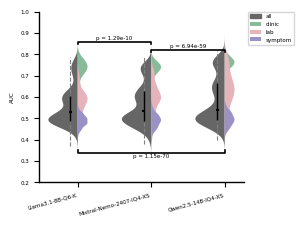

In [9]:
base_cols = ['Target', 'LLM_name', 'task_phrase', 'cot', 'persona', 'n_few_shot', 'tabular']
# fig = generate_mixed_violin_plot(agg_df_train, 'LLM_name', 0, ["Llama3.1-8B-Q6-K", "Mistral-Nemo-2407-IQ4-XS", "Qwen2.5-14B-IQ4-XS"], "Prediction performance by LLM family", True, base_cols, True)
fig = generate_mixed_violin_plot(agg_df_train, 'LLM_name', 0, ["Llama3.1-8B-Q6-K", "Mistral-Nemo-2407-IQ4-XS", "Qwen2.5-14B-IQ4-XS"], "LLM family", True, base_cols, fig_size_mm=(80,60))

In [11]:
fig.savefig("prompt_engineering_LLMfamily.svg") # , bbox_inches="tight")

In [10]:
from scipy.stats import friedmanchisquare

# Pivot to align paired observations
pivot_df = agg_df_train.pivot_table(
    index=['Target', 'task_phrase', 'cot', 'persona', 'n_few_shot', 'tabular'],
    columns='LLM_name',
    values='AUC'
).dropna()

# Extract models (adjust names exactly as they appear in your data)
qwen = pivot_df['Qwen2.5-14B-IQ4-XS']
llama = pivot_df['Llama3.1-8B-Q6-K']
mistral = pivot_df['Mistral-Nemo-2407-IQ4-XS']

# ---- 1. Global test (single P-value) ----
stat, p_value = friedmanchisquare(qwen, llama, mistral)

print(f"Friedman test P-value: {p_value:.3e}")

# ---- 2. Medians for reporting ----
median_qwen = qwen.median()
median_llama = llama.median()
median_mistral = mistral.median()

print(f"Median AUCs:")
print(f"Qwen: {median_qwen:.3f}")
print(f"LLaMA: {median_llama:.3f}")
print(f"Mistral: {median_mistral:.3f}")

Friedman test P-value: 1.193e-70
Median AUCs:
Qwen: 0.541
LLaMA: 0.528
Mistral: 0.536


In [11]:
pivot_df = agg_df_train.pivot_table(
    index=[
        'Target',
        'target_type',
        'task_phrase',
        'cot',
        'persona',
        'n_few_shot',
        'tabular'
    ],
    columns='LLM_name',
    values='AUC'
).dropna()

median_by_category = (
    pivot_df
    .groupby(level='target_type')
    .median()
)

print(median_by_category.round(3))

LLM_name     Llama3.1-8B-Q6-K  Mistral-Nemo-2407-IQ4-XS  Qwen2.5-14B-IQ4-XS
target_type                                                                
clinic                  0.726                     0.726               0.753
lab                     0.586                     0.602               0.636
symptom                 0.489                     0.488               0.495


Mean difference between 0 and 4: -0.008
p-value between 0 and 4: 1.1e-12
Mean difference between 0 and 8: -0.007
p-value between 0 and 8: 3.81e-10
Mean difference between 0 and 16: -0.000
p-value between 0 and 16: 0.888
Mean difference between 4 and 8: 0.001
p-value between 4 and 8: 0.221
Mean difference between 4 and 16: 0.007
p-value between 4 and 16: 8.07e-13
Mean difference between 8 and 16: 0.007
p-value between 8 and 16: 1.62e-11
Significant: Mean difference between 0 and 4: -0.008
  Clinic: Mean difference = -0.016
  Lab: Mean difference = -0.014
  Symptom: Mean difference = 0.001
Significant: Mean difference between 0 and 8: -0.007
  Clinic: Mean difference = -0.012
  Lab: Mean difference = -0.013
  Symptom: Mean difference = -0.000
Significant: Mean difference between 4 and 16: 0.007
  Clinic: Mean difference = 0.018
  Lab: Mean difference = 0.013
  Symptom: Mean difference = -0.001
Significant: Mean difference between 8 and 16: 0.007
  Clinic: Mean difference = 0.014
  Lab: M

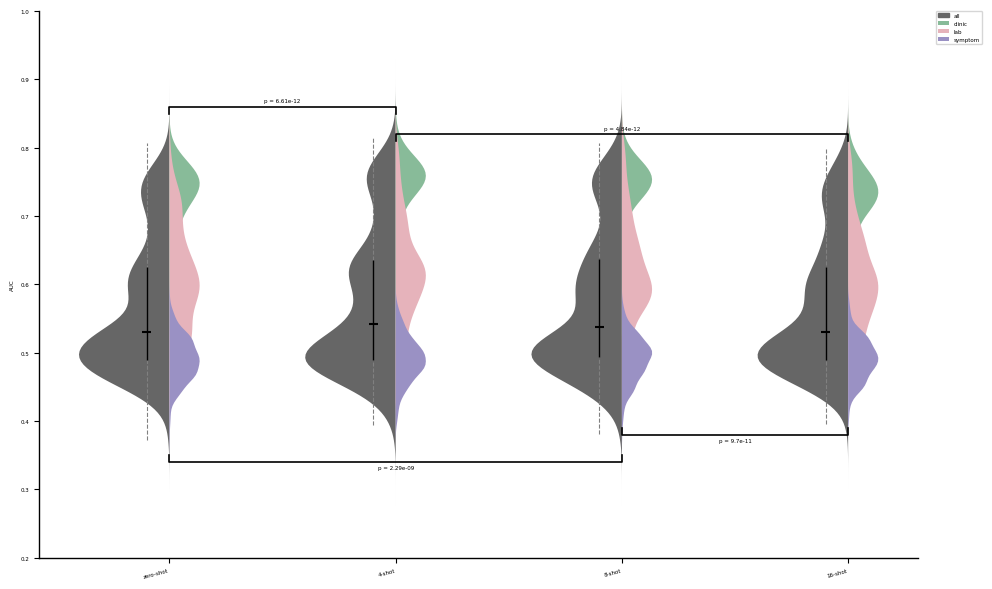

In [13]:
# fig = generate_mixed_violin_plot(agg_df_train, 'n_few_shot', 0, ["zero-shot", "4-shot", "8-shot", "16-shot"], "Prediction performance by number of few-shot examples added", True, base_cols, True)
fig = generate_mixed_violin_plot(agg_df_train, 'n_few_shot', 0, ["zero-shot", "4-shot", "8-shot", "16-shot"], "few-shot examples added", True, base_cols, True)

Mean difference between ai-model and med-onc: -0.001
p-value between ai-model and med-onc: 0.131

Creating Delta AUC Plot


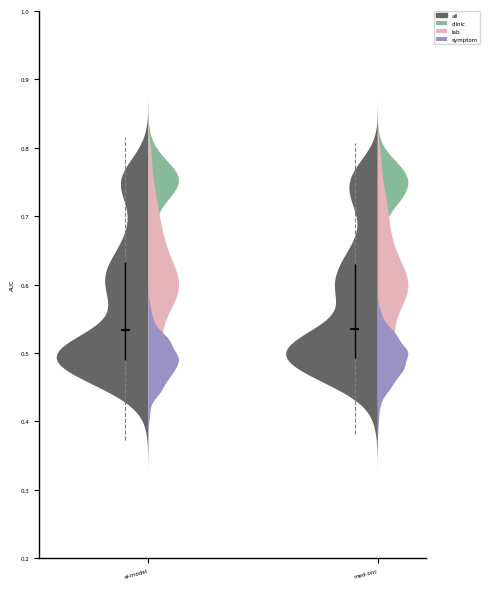

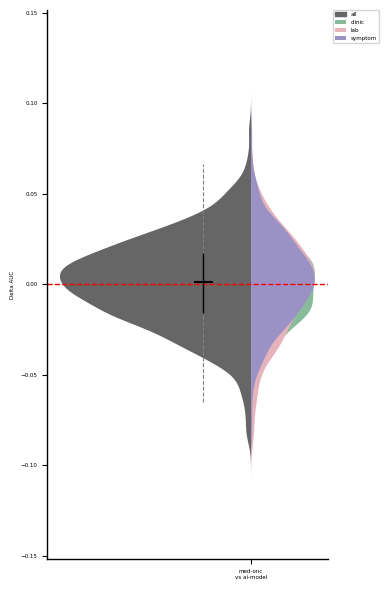


Delta AUC Statistics (med-onc - ai-model):
Overall mean delta: 0.001
Overall median delta: 0.001
Clinic mean delta: -0.002
Lab mean delta: -0.001
Symptom mean delta: 0.002


In [14]:
fig=generate_mixed_violin_plot(agg_df_train, 'persona', 0, ["ai-model", "med-onc"], "Prediction performance by persona", True, base_cols, True)

Mean difference between cot and no cot: -0.000
p-value between cot and no cot: 0.668

Creating Delta AUC Plot


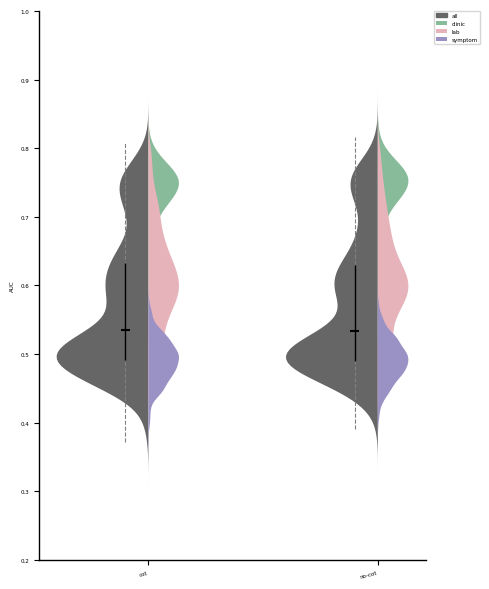

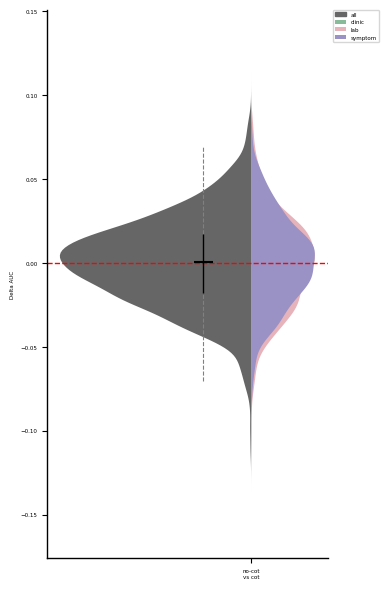


Delta AUC Statistics (no cot - cot):
Overall mean delta: 0.000
Overall median delta: 0.001
Clinic mean delta: 0.002
Lab mean delta: -0.001
Symptom mean delta: 0.001


In [15]:
fig=generate_mixed_violin_plot(agg_df_train, 'cot', 0, ["cot", "no-cot"], "Prediction performance by cot", True, base_cols, True)

Mean difference between non-simplified and simplified: 0.004
p-value between non-simplified and simplified: 1.55e-07
Significant: Mean difference between non-simplified and simplified: 0.004
  Clinic: Mean difference = -0.001
  Lab: Mean difference = 0.005
  Symptom: Mean difference = 0.004

Creating Delta AUC Plot


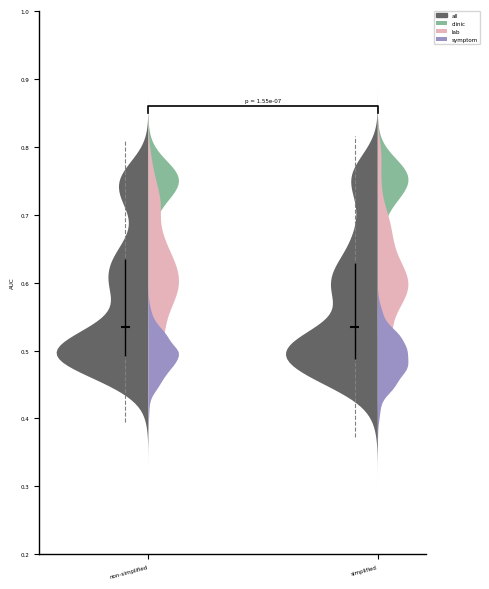

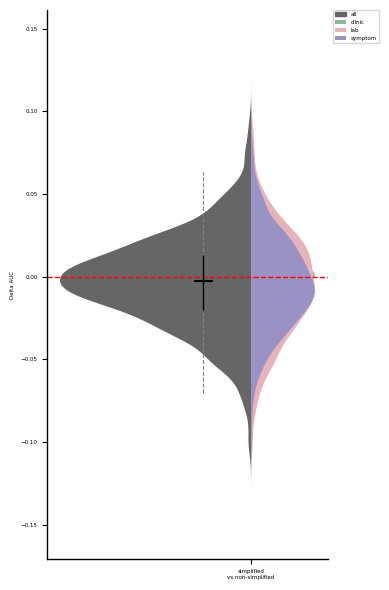


Delta AUC Statistics (simplified - non-simplified):
Overall mean delta: -0.004
Overall median delta: -0.003
Clinic mean delta: 0.001
Lab mean delta: -0.005
Symptom mean delta: -0.004


In [16]:
fig=generate_mixed_violin_plot(agg_df_train, 'task_phrase', 0, ["non-simplified", "simplified"], "Prediction performance by task phrase", True, base_cols, True)

Mean difference between note and note-tabular: 0.005
p-value between note and note-tabular: 4.04e-08
Significant: Mean difference between note and note-tabular: 0.005
  Clinic: Mean difference = -0.019
  Lab: Mean difference = -0.008
  Symptom: Mean difference = 0.023

Creating Delta AUC Plot


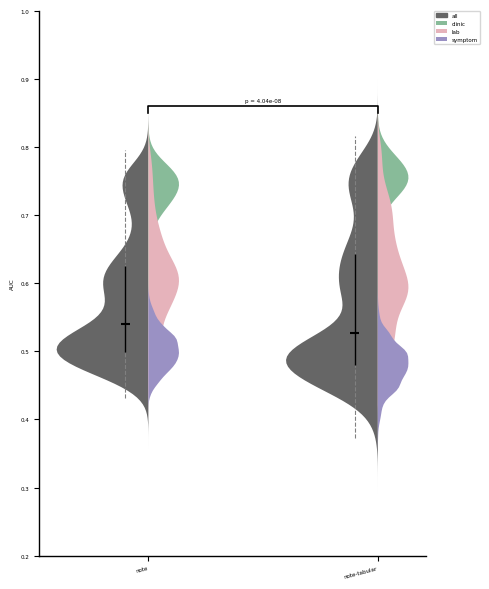

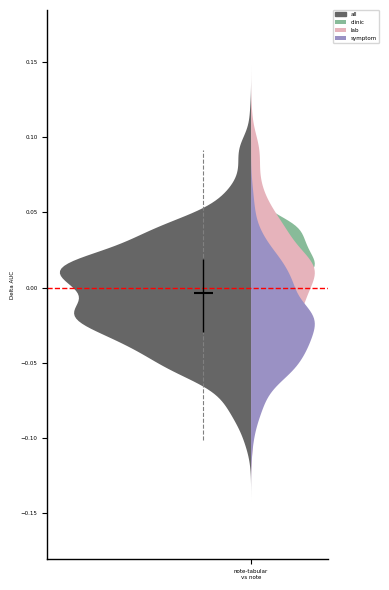


Delta AUC Statistics (note-tabular - note):
Overall mean delta: -0.005
Overall median delta: -0.004
Clinic mean delta: 0.019
Lab mean delta: 0.008
Symptom mean delta: -0.023


In [17]:
fig=generate_mixed_violin_plot(agg_df_train, 'tabular', 0, ["note", "note-tabular"], "Prediction performance by note type", True, base_cols, True)


med onc vs
 ai model (med-onc vs ai-model):
  Mean delta AUC: 0.001
  Median delta AUC: 0.001
  Wilcoxon p-value: 0.131
  Clinic mean delta: -0.002
  Lab mean delta: -0.001
  Symptom mean delta: 0.002

no CoT vs
 CoT (no cot vs cot):
  Mean delta AUC: 0.000
  Median delta AUC: 0.001
  Wilcoxon p-value: 0.668
  Clinic mean delta: 0.002
  Lab mean delta: -0.001
  Symptom mean delta: 0.001

simplified vs
 precise target definition (simplified vs non-simplified):
  Mean delta AUC: -0.004
  Median delta AUC: -0.003
  Wilcoxon p-value: 1.55e-07
  Clinic mean delta: 0.001
  Lab mean delta: -0.005
  Symptom mean delta: -0.004

tabular inclusion vs
 note only (note-tabular vs note):
  Mean delta AUC: -0.005
  Median delta AUC: -0.004
  Wilcoxon p-value: 4.04e-08
  Clinic mean delta: 0.019
  Lab mean delta: 0.008
  Symptom mean delta: -0.023


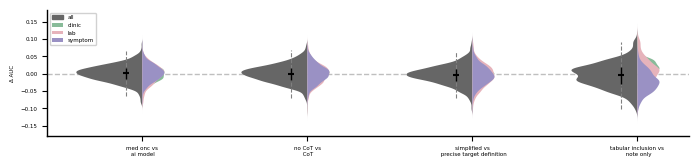

In [18]:
# Define your comparisons
comparisons = [
    {
        'col_name': 'persona', 
        'labels': ['ai-model', 'med-onc'], 
        'title': 'med onc vs\n ai model'
    },
    {
        'col_name': 'cot', 
        'labels': ['cot', 'no cot'], 
        'title': 'no CoT vs\n CoT'
    },
    {
        'col_name': 'task_phrase', 
        'labels': ['non-simplified', 'simplified'], 
        'title': 'simplified vs\n precise target definition'
    },
    {
        'col_name': 'tabular', 
        'labels': ['note', 'note-tabular'], 
        'title': 'tabular inclusion vs\n note only'
    }
]

# Call the function
fig = generate_multi_delta_violin_plot(
    agg_df_train, 
    comparisons, 
    jitter=0,  # Use 0 for KDE, non-zero for jittered points
    plot_title=None,
    base_cols=base_cols,
    fig_size_mm=(180, 45)
)

In [19]:
fig.savefig("prompt_engineering_binary_comparisons.svg")#, bbox_inches="tight")